# Random Forest Model — Stock Return Prediction & Ranking

## Objective
Build a Random Forest classifier to predict weekly stock return **direction** (up/down) for 15 stocks and rank them for portfolio allocation.

**Stocks:** AAPL, MSFT, GOOGL, AMZN, NVDA, META, TSLA, JPM, GS, JNJ, PFE, XOM, CVX, WMT, BA

**Approach:** Binary classification (up vs down). Random Forest is an ensemble of decision trees trained via bagging — each tree sees a random subset of data and features. The final prediction is the majority vote (or probability average) across all trees. This reduces variance compared to a single decision tree and naturally handles nonlinear relationships between features.

**Key concept covered:** Ensemble learning via bagging, feature importance, out-of-bag error estimation.

**Important — No Lookahead Bias:** All features are shifted by 1 week so that when predicting week T, the model only sees information available at the end of week T-1. This is critical for a realistic simulation.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

print('All imports successful.')

All imports successful.


## 2. Configuration

In [2]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'GS', 'JNJ', 'PFE', 'XOM', 'CVX', 'WMT', 'BA']

OUT_DIR = '../../data/results'
os.makedirs(OUT_DIR, exist_ok=True)

FILES = {
    'AAPL':  '../../data/Apple.csv',
    'MSFT':  '../../data/MSFT.csv',
    'GOOGL': '../../data/google.csv',
    'AMZN':  '../../data/Amazon.csv',
    'NVDA':  '../../data/NVIDIA.csv',
    'META':  '../../data/META.csv',
    'TSLA':  '../../data/TSLA.csv',
    'JPM':   '../../data/JPM.csv',
    'GS':    '../../data/GSach.csv',
    'JNJ':   '../../data/JNJ.csv',
    'PFE':   '../../data/PFE.csv',
    'XOM':   '../../data/XOM.csv',
    'CVX':   '../../data/CVX.csv',
    'WMT':   '../../data/WMT.csv',
    'BA':    '../../data/BA.csv',
}

COLORS = {
    'AAPL': '#1f77b4', 'MSFT': '#ff7f0e', 'GOOGL': '#2ca02c',
    'AMZN': '#d62728', 'NVDA': '#9467bd', 'META': '#8c564b',
    'TSLA': '#e377c2', 'JPM': '#7f7f7f', 'GS': '#bcbd22',
    'JNJ': '#17becf', 'PFE': '#aec7e8', 'XOM': '#ffbb78',
    'CVX': '#98df8a', 'WMT': '#ff9896', 'BA': '#c5b0d5'
}

print('Configuration set.')
print(f'Total stocks: {len(TICKERS)}')

Configuration set.
Total stocks: 15


## 3. Load Raw Data & Engineer Features

All features are shifted by 1 week (`.shift(1)`) to ensure no lookahead bias. When predicting the return for week T, the model only sees data available at the close of week T-1.

In [3]:
def load_file(ticker, path):
    try:
        df = pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding='latin1')
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    for col in ['Open', 'High', 'Low', 'Close']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['Volume'] = pd.to_numeric(df['Volume'].astype(str).str.replace(',', ''), errors='coerce')
    return df.sort_values('Date').dropna().reset_index(drop=True)

frames = []
for ticker, path in FILES.items():
    df = load_file(ticker, path)
    df = df.set_index('Date')

    w = pd.DataFrame()
    w['Close']  = df['Close'].resample('W-FRI').last()
    w['High']   = df['High'].resample('W-FRI').max()
    w['Low']    = df['Low'].resample('W-FRI').min()
    w['Open']   = df['Open'].resample('W-FRI').first()
    w['Volume'] = df['Volume'].resample('W-FRI').sum()

    # Target: this week's return — NOT shifted, this is what we predict
    w['Weekly_Return'] = w['Close'].pct_change() * 100

    # --- All features below are shifted by 1 week to prevent lookahead ---

    # Lagged returns
    w['ret_lag1'] = w['Close'].pct_change(1).shift(1) * 100
    w['ret_lag2'] = w['Close'].pct_change(1).shift(2) * 100
    w['ret_2w']   = w['Close'].pct_change(2).shift(1) * 100
    w['ret_4w']   = w['Close'].pct_change(4).shift(1) * 100
    w['ret_8w']   = w['Close'].pct_change(8).shift(1) * 100

    # RSI-14
    delta = w['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    w['rsi_14'] = ((100 - (100 / (1 + rs))) / 100).shift(1)

    # MACD histogram
    ema12  = w['Close'].ewm(span=12).mean()
    ema26  = w['Close'].ewm(span=26).mean()
    macd   = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    w['macd_hist'] = ((macd - signal) / w['Close']).shift(1)

    # Bollinger Bands
    bb_mid = w['Close'].rolling(20).mean()
    bb_std = w['Close'].rolling(20).std()
    w['bb_pct']   = ((w['Close'] - bb_mid) / (2 * bb_std.replace(0, np.nan))).shift(1)
    w['bb_width'] = ((4 * bb_std) / bb_mid.replace(0, np.nan)).shift(1)

    # Rolling volatility
    weekly_ret  = w['Close'].pct_change() * 100
    w['vol_4w'] = weekly_ret.rolling(4).std().shift(1)
    w['vol_8w'] = weekly_ret.rolling(8).std().shift(1)

    # Price vs moving averages
    w['price_to_sma5']  = (w['Close'] / w['Close'].rolling(5).mean() - 1).shift(1)
    w['price_to_sma20'] = (w['Close'] / w['Close'].rolling(20).mean() - 1).shift(1)

    # ATR
    tr = pd.concat([
        w['High'] - w['Low'],
        (w['High'] - w['Close'].shift(1)).abs(),
        (w['Low']  - w['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    w['atr_pct'] = (tr.rolling(14).mean() / w['Close']).shift(1)

    # Volume ratio
    w['vol_ratio'] = (w['Volume'] / w['Volume'].rolling(10).mean().replace(0, np.nan)).shift(1)

    w['Ticker'] = ticker
    w = w.dropna().reset_index()
    frames.append(w)
    print(f'{ticker}: {len(w)} weeks, {w["Date"].min().date()} to {w["Date"].max().date()}')

raw = pd.concat(frames).sort_values(['Date', 'Ticker']).reset_index(drop=True)
print(f'\nTotal rows: {len(raw)}')

AAPL: 563 weeks, 2015-05-22 to 2026-02-27
MSFT: 563 weeks, 2015-05-22 to 2026-02-27
GOOGL: 563 weeks, 2015-05-22 to 2026-02-27
AMZN: 563 weeks, 2015-05-22 to 2026-02-27
NVDA: 563 weeks, 2015-05-22 to 2026-02-27
META: 563 weeks, 2015-05-22 to 2026-02-27
TSLA: 563 weeks, 2015-05-22 to 2026-02-27
JPM: 563 weeks, 2015-05-22 to 2026-02-27
GS: 563 weeks, 2015-05-22 to 2026-02-27
JNJ: 563 weeks, 2015-05-22 to 2026-02-27
PFE: 563 weeks, 2015-05-22 to 2026-02-27
XOM: 563 weeks, 2015-05-22 to 2026-02-27
CVX: 563 weeks, 2015-05-22 to 2026-02-27
WMT: 563 weeks, 2015-05-22 to 2026-02-27
BA: 563 weeks, 2015-05-22 to 2026-02-27

Total rows: 8445


## 4. Cross-Sectional Features

How each stock compares to the full universe each week — computed on already-shifted features so no lookahead.

In [4]:
for feat in ['ret_lag1', 'vol_4w', 'rsi_14']:
    cross   = raw.pivot_table(index='Date', columns='Ticker', values=feat)
    cs_rank = cross.rank(axis=1, pct=True)
    cs_mean = cross.mean(axis=1)
    cs_std  = cross.std(axis=1).replace(0, np.nan)
    cs_z    = cross.sub(cs_mean, axis=0).div(cs_std, axis=0)

    for ticker in TICKERS:
        mask  = raw['Ticker'] == ticker
        dates = raw.loc[mask, 'Date']
        if ticker in cs_rank.columns:
            raw.loc[mask, f'cs_rank_{feat}'] = cs_rank[ticker].reindex(dates.values).values
            raw.loc[mask, f'cs_z_{feat}']    = cs_z[ticker].reindex(dates.values).values

raw = raw.dropna().reset_index(drop=True)

train = raw[raw['Date'] <= '2021-12-31'].copy()
val   = raw[(raw['Date'] >= '2022-01-01') & (raw['Date'] <= '2023-12-31')].copy()
test  = raw[raw['Date'] >= '2024-01-01'].copy()

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')
print(f'Date range: {raw["Date"].min().date()} to {raw["Date"].max().date()}')
print(f'\nClass balance (% weeks with positive return):')
for ticker in TICKERS:
    t = train[train['Ticker'] == ticker]
    up_pct = (t['Weekly_Return'] > 0).mean()
    print(f'  {ticker}: {up_pct:.1%} up / {1-up_pct:.1%} down')

Train: 5190 | Val: 1560 | Test: 1695
Date range: 2015-05-22 to 2026-02-27

Class balance (% weeks with positive return):
  AAPL: 60.1% up / 39.9% down
  MSFT: 61.3% up / 38.7% down
  GOOGL: 57.8% up / 42.2% down
  AMZN: 59.2% up / 40.8% down
  NVDA: 59.2% up / 40.8% down
  META: 57.8% up / 42.2% down
  TSLA: 56.6% up / 43.4% down
  JPM: 52.6% up / 47.4% down
  GS: 51.7% up / 48.3% down
  JNJ: 56.1% up / 43.9% down
  PFE: 54.6% up / 45.4% down
  XOM: 48.8% up / 51.2% down
  CVX: 51.2% up / 48.8% down
  WMT: 53.2% up / 46.8% down
  BA: 53.2% up / 46.8% down


## 5. Feature Columns & Target

In [5]:
feature_cols = [
    'ret_lag1', 'ret_lag2', 'ret_2w', 'ret_4w', 'ret_8w',
    'rsi_14', 'macd_hist', 'bb_pct', 'bb_width',
    'vol_4w', 'vol_8w', 'price_to_sma5', 'price_to_sma20',
    'atr_pct', 'vol_ratio',
    'cs_rank_ret_lag1', 'cs_z_ret_lag1',
    'cs_rank_vol_4w',   'cs_z_vol_4w',
    'cs_rank_rsi_14',   'cs_z_rsi_14'
]

print(f'Features ({len(feature_cols)}):')
for i, f in enumerate(feature_cols):
    print(f'  {i+1:2d}. {f}')
print('\nTarget: 1 if Weekly_Return > 0 else 0')
print('No lookahead: all features use only data available at end of prior week.')

Features (21):
   1. ret_lag1
   2. ret_lag2
   3. ret_2w
   4. ret_4w
   5. ret_8w
   6. rsi_14
   7. macd_hist
   8. bb_pct
   9. bb_width
  10. vol_4w
  11. vol_8w
  12. price_to_sma5
  13. price_to_sma20
  14. atr_pct
  15. vol_ratio
  16. cs_rank_ret_lag1
  17. cs_z_ret_lag1
  18. cs_rank_vol_4w
  19. cs_z_vol_4w
  20. cs_rank_rsi_14
  21. cs_z_rsi_14

Target: 1 if Weekly_Return > 0 else 0
No lookahead: all features use only data available at end of prior week.


## 6. Explore Weekly Returns

In [6]:
vol_stats = []
for ticker in TICKERS:
    data = raw[raw['Ticker'] == ticker]['Weekly_Return']
    vol_stats.append({
        'Ticker': ticker,
        'Mean (%)': round(data.mean(), 2),
        'Std Dev (%)': round(data.std(), 2),
        'Min (%)': round(data.min(), 2),
        'Max (%)': round(data.max(), 2),
        'Up Weeks (%)': round((data > 0).mean() * 100, 1)
    })
vol_df = pd.DataFrame(vol_stats).set_index('Ticker')
print('Weekly Return Statistics:')
print(vol_df.to_string())

Weekly Return Statistics:
        Mean (%)  Std Dev (%)  Min (%)  Max (%)  Up Weeks (%)
Ticker                                                       
AAPL        0.45         3.85   -17.53    14.74          57.0
MSFT        0.42         3.21   -13.52    12.41          57.4
GOOGL       0.51         3.90   -12.02    25.78          57.0
AMZN        0.49         4.17   -14.45    16.26          56.5
NVDA        1.23         6.31   -20.04    30.18          58.3
META        0.49         4.90   -23.70    24.49          55.8
TSLA        0.88         8.05   -25.87    33.34          53.6
JPM         0.34         3.69   -19.64    22.26          55.2
GS          0.34         4.16   -21.88    25.41          52.9
JNJ         0.19         2.40   -10.72     8.94          54.4
PFE         0.02         3.24   -11.82    15.19          52.0
XOM         0.17         3.79   -20.07    16.74          52.4
CVX         0.17         3.86   -28.81    16.70          53.5
WMT         0.32         2.95   -19.49    11

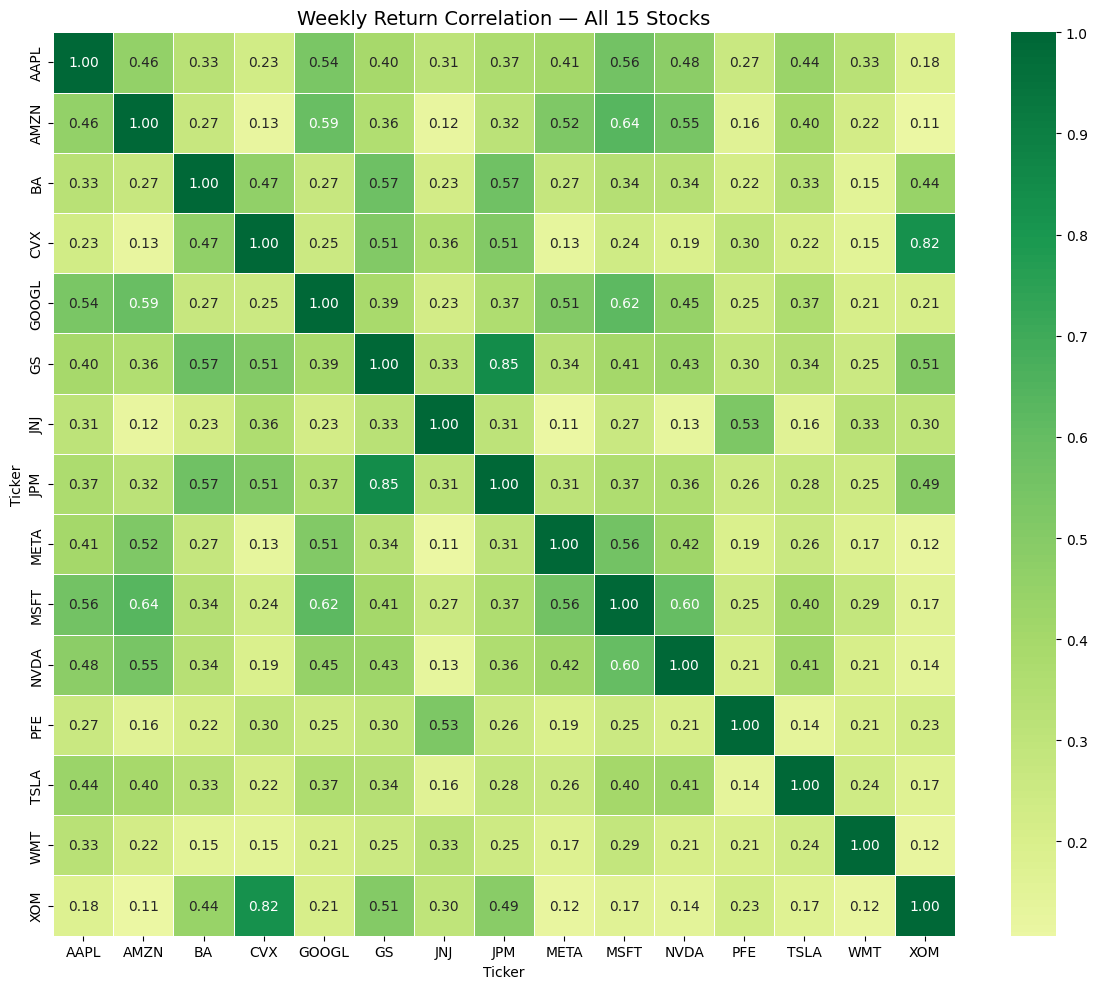

Saved: ../../data/results/rf_correlation_heatmap.png


In [7]:
ret_pivot = raw.pivot_table(index='Date', columns='Ticker', values='Weekly_Return')
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(ret_pivot.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Weekly Return Correlation — All 15 Stocks', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_correlation_heatmap.png')

## 7. Train Random Forest for All Stocks

A separate model per stock. Random Forest takes a single week's features as input — no sequence/lookback window needed unlike LSTM.

**Hyperparameters:**
- `n_estimators=200` — 200 trees
- `max_depth=6` — prevents overfitting
- `min_samples_leaf=5` — each leaf needs at least 5 samples
- `max_features='sqrt'` — each split considers sqrt(n_features) candidates
- `class_weight='balanced'` — handles class imbalance
- `oob_score=True` — free validation via out-of-bag samples

In [8]:
all_predictions = []
all_metrics = {}
all_models = {}

for ticker in TICKERS:
    print(f'\n{"="*50}')
    print(f'  Training Random Forest for {ticker}')
    print(f'{"="*50}')

    tr = train[train['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)
    va = val[val['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)
    te = test[test['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)

    X_tr = tr[feature_cols].values
    y_tr = (tr['Weekly_Return'] > 0).astype(int).values
    X_va = va[feature_cols].values
    y_va = (va['Weekly_Return'] > 0).astype(int).values
    X_te = te[feature_cols].values
    y_te = (te['Weekly_Return'] > 0).astype(int).values

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_va = scaler.transform(X_va)
    X_te = scaler.transform(X_te)

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)
    all_models[ticker] = (model, scaler)

    val_acc  = accuracy_score(y_va, model.predict(X_va))
    test_acc = accuracy_score(y_te, model.predict(X_te))
    oob_acc  = model.oob_score_
    probs    = model.predict_proba(X_te)[:, 1]

    print(f'  Train: {len(X_tr)} | Val: {len(X_va)} | Test: {len(X_te)}')
    print(f'  OOB Accuracy:  {oob_acc:.2%}')
    print(f'  Val Accuracy:  {val_acc:.2%}')
    print(f'  Test Accuracy: {test_acc:.2%}')
    print(f'  Prob range: [{probs.min():.3f} - {probs.max():.3f}], std: {probs.std():.3f}')

    all_metrics[ticker] = {
        'OOB Accuracy':  round(oob_acc, 4),
        'Val Accuracy':  round(val_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Prob Std':      round(probs.std(), 4),
        'Test Samples':  len(y_te)
    }

    raw_ret = te['Weekly_Return'].values
    for i in range(len(probs)):
        all_predictions.append({
            'Date':             pd.Timestamp(te['Date'].iloc[i]),
            'Ticker':           ticker,
            'Predicted_Return': float(probs[i]),
            'Actual_Return':    float(raw_ret[i]),
            'Pred_Direction':   int(probs[i] > 0.5),
            'Actual_Direction': int(y_te[i])
        })

print('\n' + '='*50)
print('  RESULTS SUMMARY')
print('='*50)
for t, m in all_metrics.items():
    print(f'  {t}: Test={m["Test Accuracy"]:.1%}  OOB={m["OOB Accuracy"]:.1%}  Val={m["Val Accuracy"]:.1%}')


  Training Random Forest for AAPL
  Train: 346 | Val: 104 | Test: 113
  OOB Accuracy:  51.73%
  Val Accuracy:  54.81%
  Test Accuracy: 48.67%
  Prob range: [0.359 - 0.713], std: 0.083

  Training Random Forest for MSFT
  Train: 346 | Val: 104 | Test: 113
  OOB Accuracy:  50.29%
  Val Accuracy:  45.19%
  Test Accuracy: 48.67%
  Prob range: [0.294 - 0.786], std: 0.109

  Training Random Forest for GOOGL
  Train: 346 | Val: 104 | Test: 113
  OOB Accuracy:  51.16%
  Val Accuracy:  49.04%
  Test Accuracy: 40.71%
  Prob range: [0.318 - 0.680], std: 0.087

  Training Random Forest for AMZN
  Train: 346 | Val: 104 | Test: 113
  OOB Accuracy:  52.89%
  Val Accuracy:  46.15%
  Test Accuracy: 59.29%
  Prob range: [0.331 - 0.734], std: 0.087

  Training Random Forest for NVDA
  Train: 346 | Val: 104 | Test: 113
  OOB Accuracy:  53.18%
  Val Accuracy:  46.15%
  Test Accuracy: 52.21%
  Prob range: [0.262 - 0.676], std: 0.095

  Training Random Forest for META
  Train: 346 | Val: 104 | Test: 113
  O

## 8. Save Predictions

In [9]:
pred_df = pd.DataFrame(all_predictions)
pred_df = pred_df.sort_values(['Date', 'Ticker']).reset_index(drop=True)

pred_df[['Date', 'Ticker', 'Predicted_Return']].to_csv(
    f'{OUT_DIR}/rf_predictions.csv', index=False
)

print(f'Saved: {OUT_DIR}/rf_predictions.csv')
print(f'Shape: {pred_df.shape}')
pred_df.head(10)

Saved: ../../data/results/rf_predictions.csv
Shape: (1695, 6)


,Date,Ticker,Predicted_Return,Actual_Return,Pred_Direction,Actual_Direction
0,2024-01-05,AAPL,0.532604,-5.895185,1,0
1,2024-01-05,AMZN,0.599150,-4.409635,1,0
2,2024-01-05,BA,0.448036,-4.473260,0,0
3,2024-01-05,CVX,0.511829,0.831322,1,1
4,2024-01-05,GOOGL,0.497526,-2.834849,0,0
5,2024-01-05,GS,0.603420,0.173679,1,1
6,2024-01-05,JNJ,0.483724,2.800817,0,1
7,2024-01-05,JPM,0.503243,1.275720,1,1
8,2024-01-05,META,0.375141,-0.567861,0,0
9,2024-01-05,MSFT,0.452873,-2.204553,0,0


## 9. Accuracy Summary

  RANDOM FOREST MODEL — FINAL METRICS
        OOB Accuracy  Val Accuracy  Test Accuracy  Prob Std  Test Samples
Ticker                                                                   
AAPL          0.5173        0.5481         0.4867    0.0829         113.0
MSFT          0.5029        0.4519         0.4867    0.1086         113.0
GOOGL         0.5116        0.4904         0.4071    0.0872         113.0
AMZN          0.5289        0.4615         0.5929    0.0873         113.0
NVDA          0.5318        0.4615         0.5221    0.0948         113.0
META          0.4942        0.4712         0.5221    0.1291         113.0
TSLA          0.5231        0.4904         0.4956    0.0942         113.0
JPM           0.5549        0.5288         0.4690    0.1156         113.0
GS            0.4884        0.5288         0.4602    0.0669         113.0
JNJ           0.5231        0.5192         0.5133    0.0970         113.0
PFE           0.5029        0.5096         0.5133    0.0878         113.0


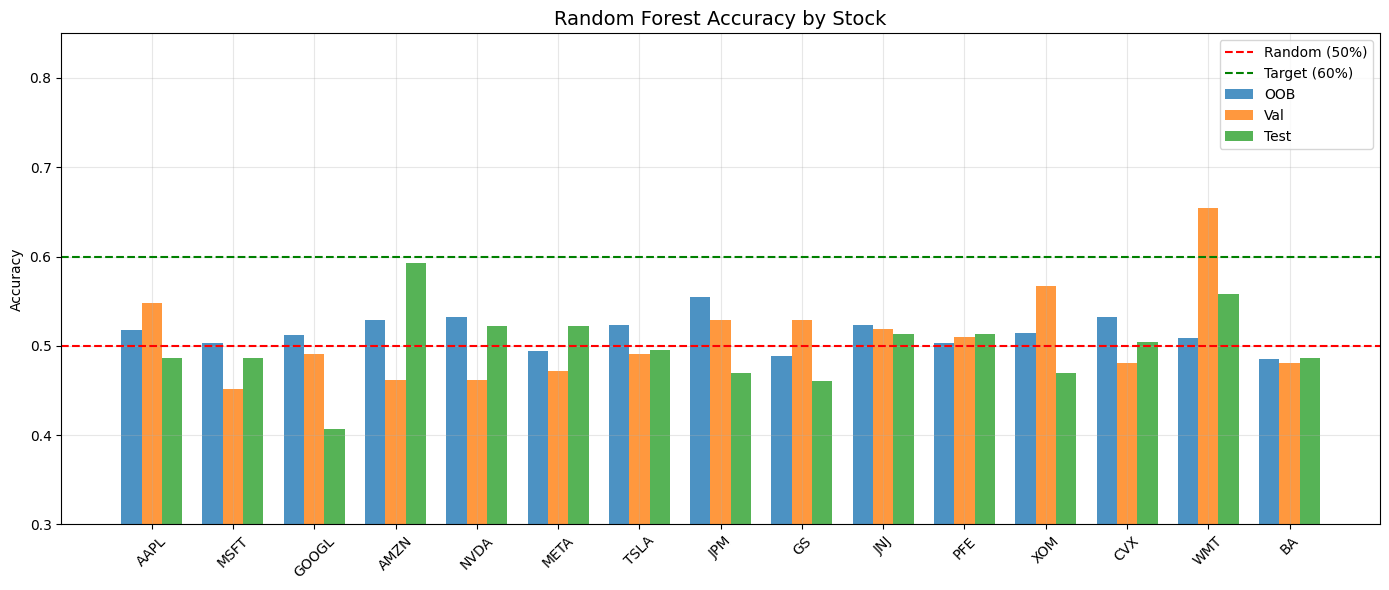

Saved: ../../data/results/rf_accuracy_bar.png


In [10]:
metrics_df = pd.DataFrame(all_metrics).T
metrics_df.index.name = 'Ticker'

print('='*65)
print('  RANDOM FOREST MODEL — FINAL METRICS')
print('='*65)
print(metrics_df.to_string())

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(TICKERS))
width = 0.25
ax.bar(x - width, metrics_df['OOB Accuracy'],  width, label='OOB',  alpha=0.8, color='#1f77b4')
ax.bar(x,         metrics_df['Val Accuracy'],  width, label='Val',  alpha=0.8, color='#ff7f0e')
ax.bar(x + width, metrics_df['Test Accuracy'], width, label='Test', alpha=0.8, color='#2ca02c')
ax.axhline(y=0.5, color='red',   linestyle='--', linewidth=1.5, label='Random (50%)')
ax.axhline(y=0.6, color='green', linestyle='--', linewidth=1.5, label='Target (60%)')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=45)
ax.set_title('Random Forest Accuracy by Stock', fontsize=14)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.3, 0.85)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_accuracy_bar.png')

## 10. Predicted Probability Over Time

Unlike LSTM which uses sequential context, Random Forest uses only the prior week's features. The probability reflects how similar last week's feature pattern is to historical up-weeks in the training data.

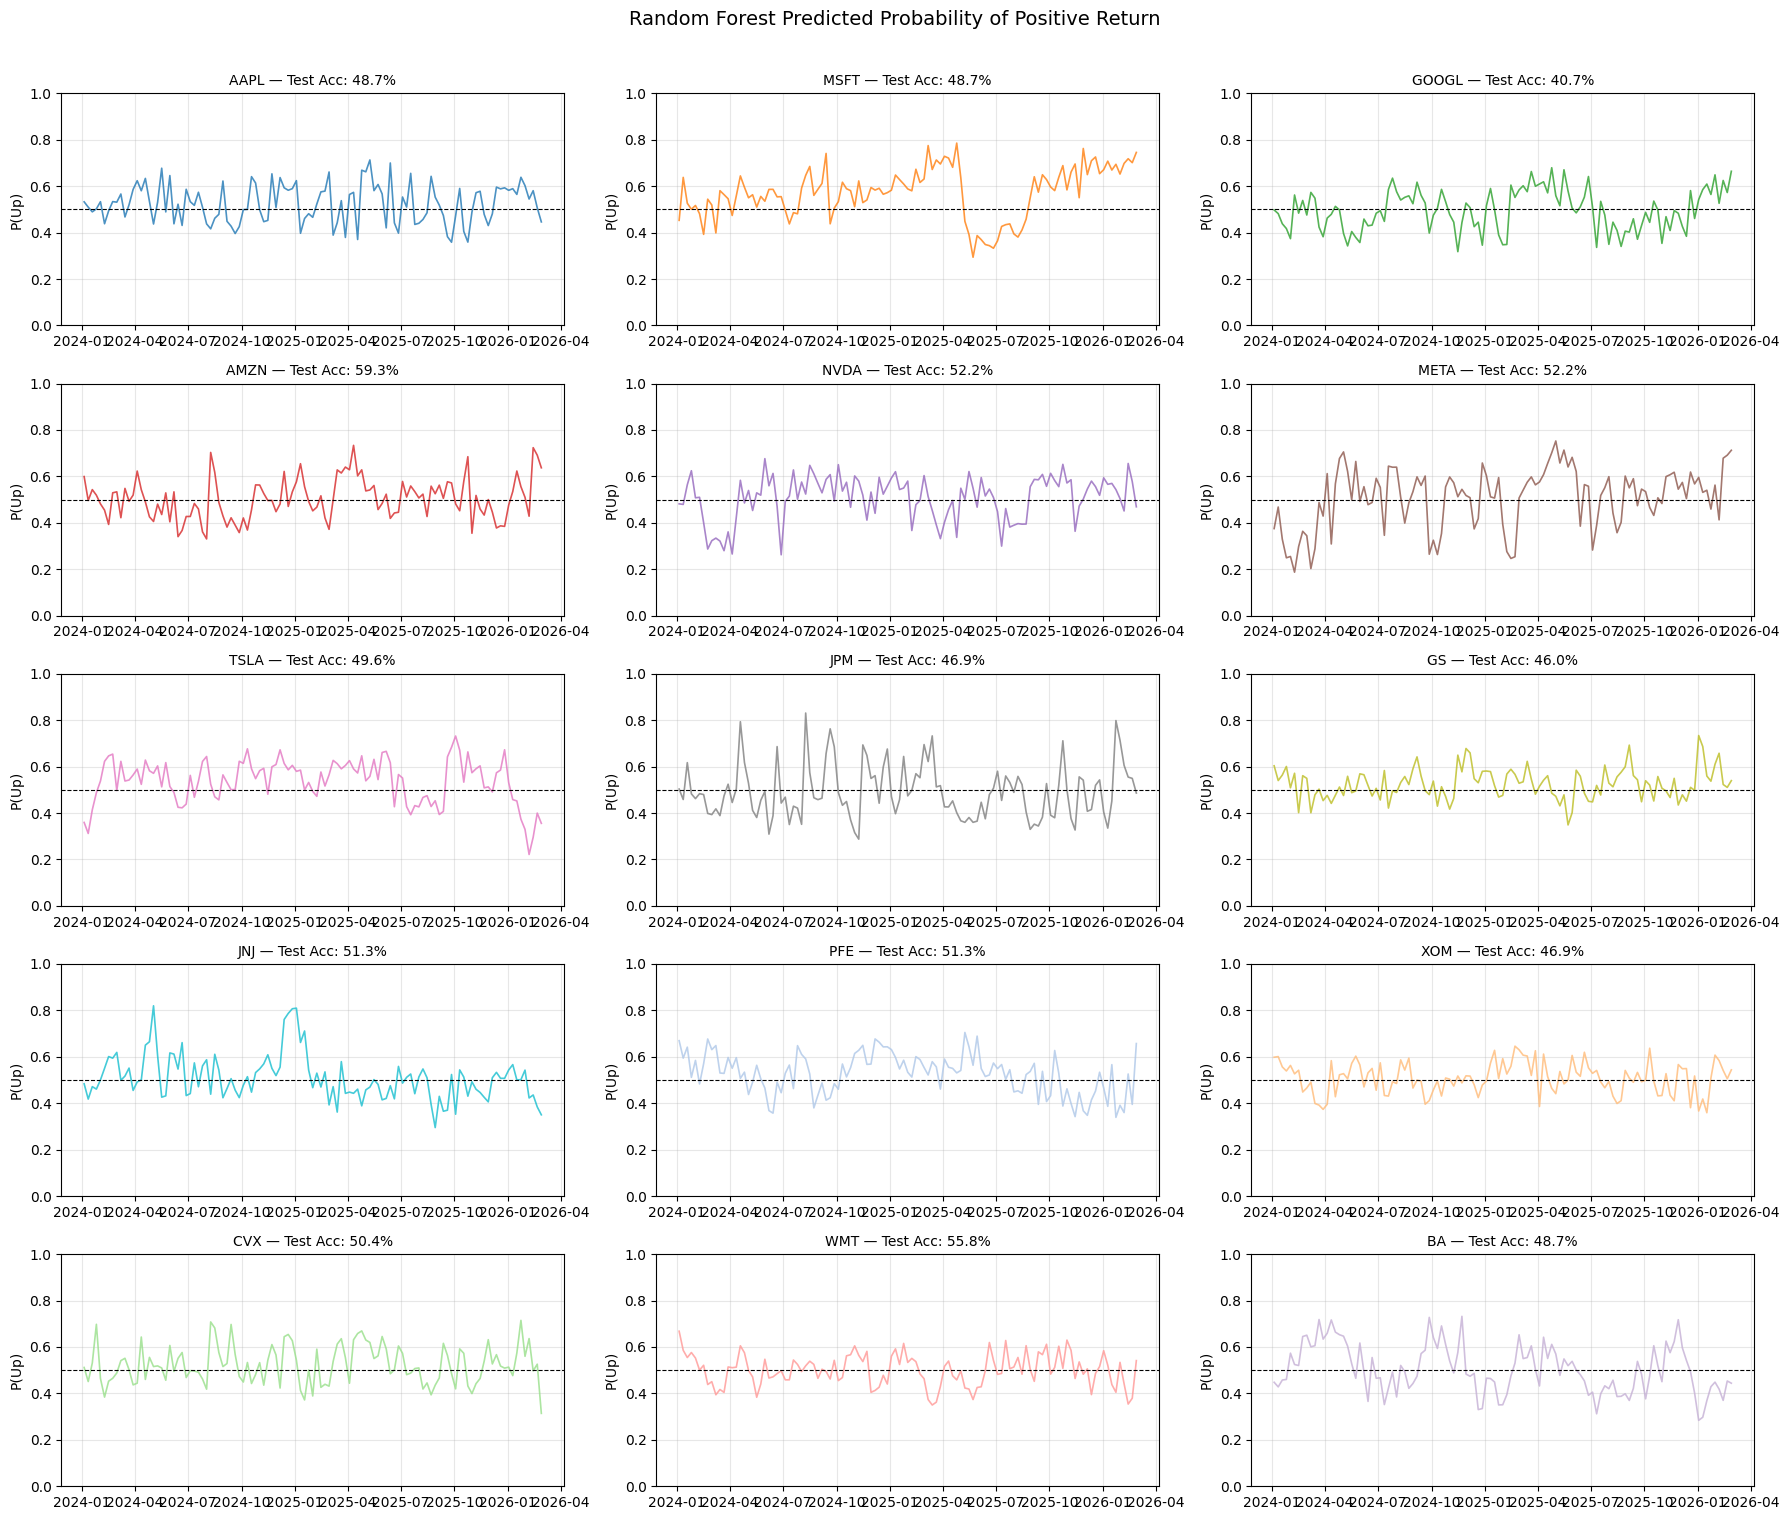

Saved: ../../data/results/rf_probability_over_time.png


In [11]:
n_cols = 3
n_rows = (len(TICKERS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    td = pred_df[pred_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(td['Date'], td['Predicted_Return'], alpha=0.8, linewidth=1.2,
            color=COLORS.get(ticker, '#333333'))
    ax.axhline(y=0.5, color='black', linewidth=0.8, linestyle='--')
    acc = all_metrics[ticker]['Test Accuracy']
    ax.set_title(f'{ticker} — Test Acc: {acc:.1%}', fontsize=10)
    ax.set_ylabel('P(Up)')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Random Forest Predicted Probability of Positive Return', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_probability_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_probability_over_time.png')

## 11. Buy/Sell Signals

**Decision rule for an investor:**
- **P(Up) > 0.5 → Buy** — model predicts stock will rise next week
- **P(Up) ≤ 0.5 → Avoid** — model predicts stock will fall next week

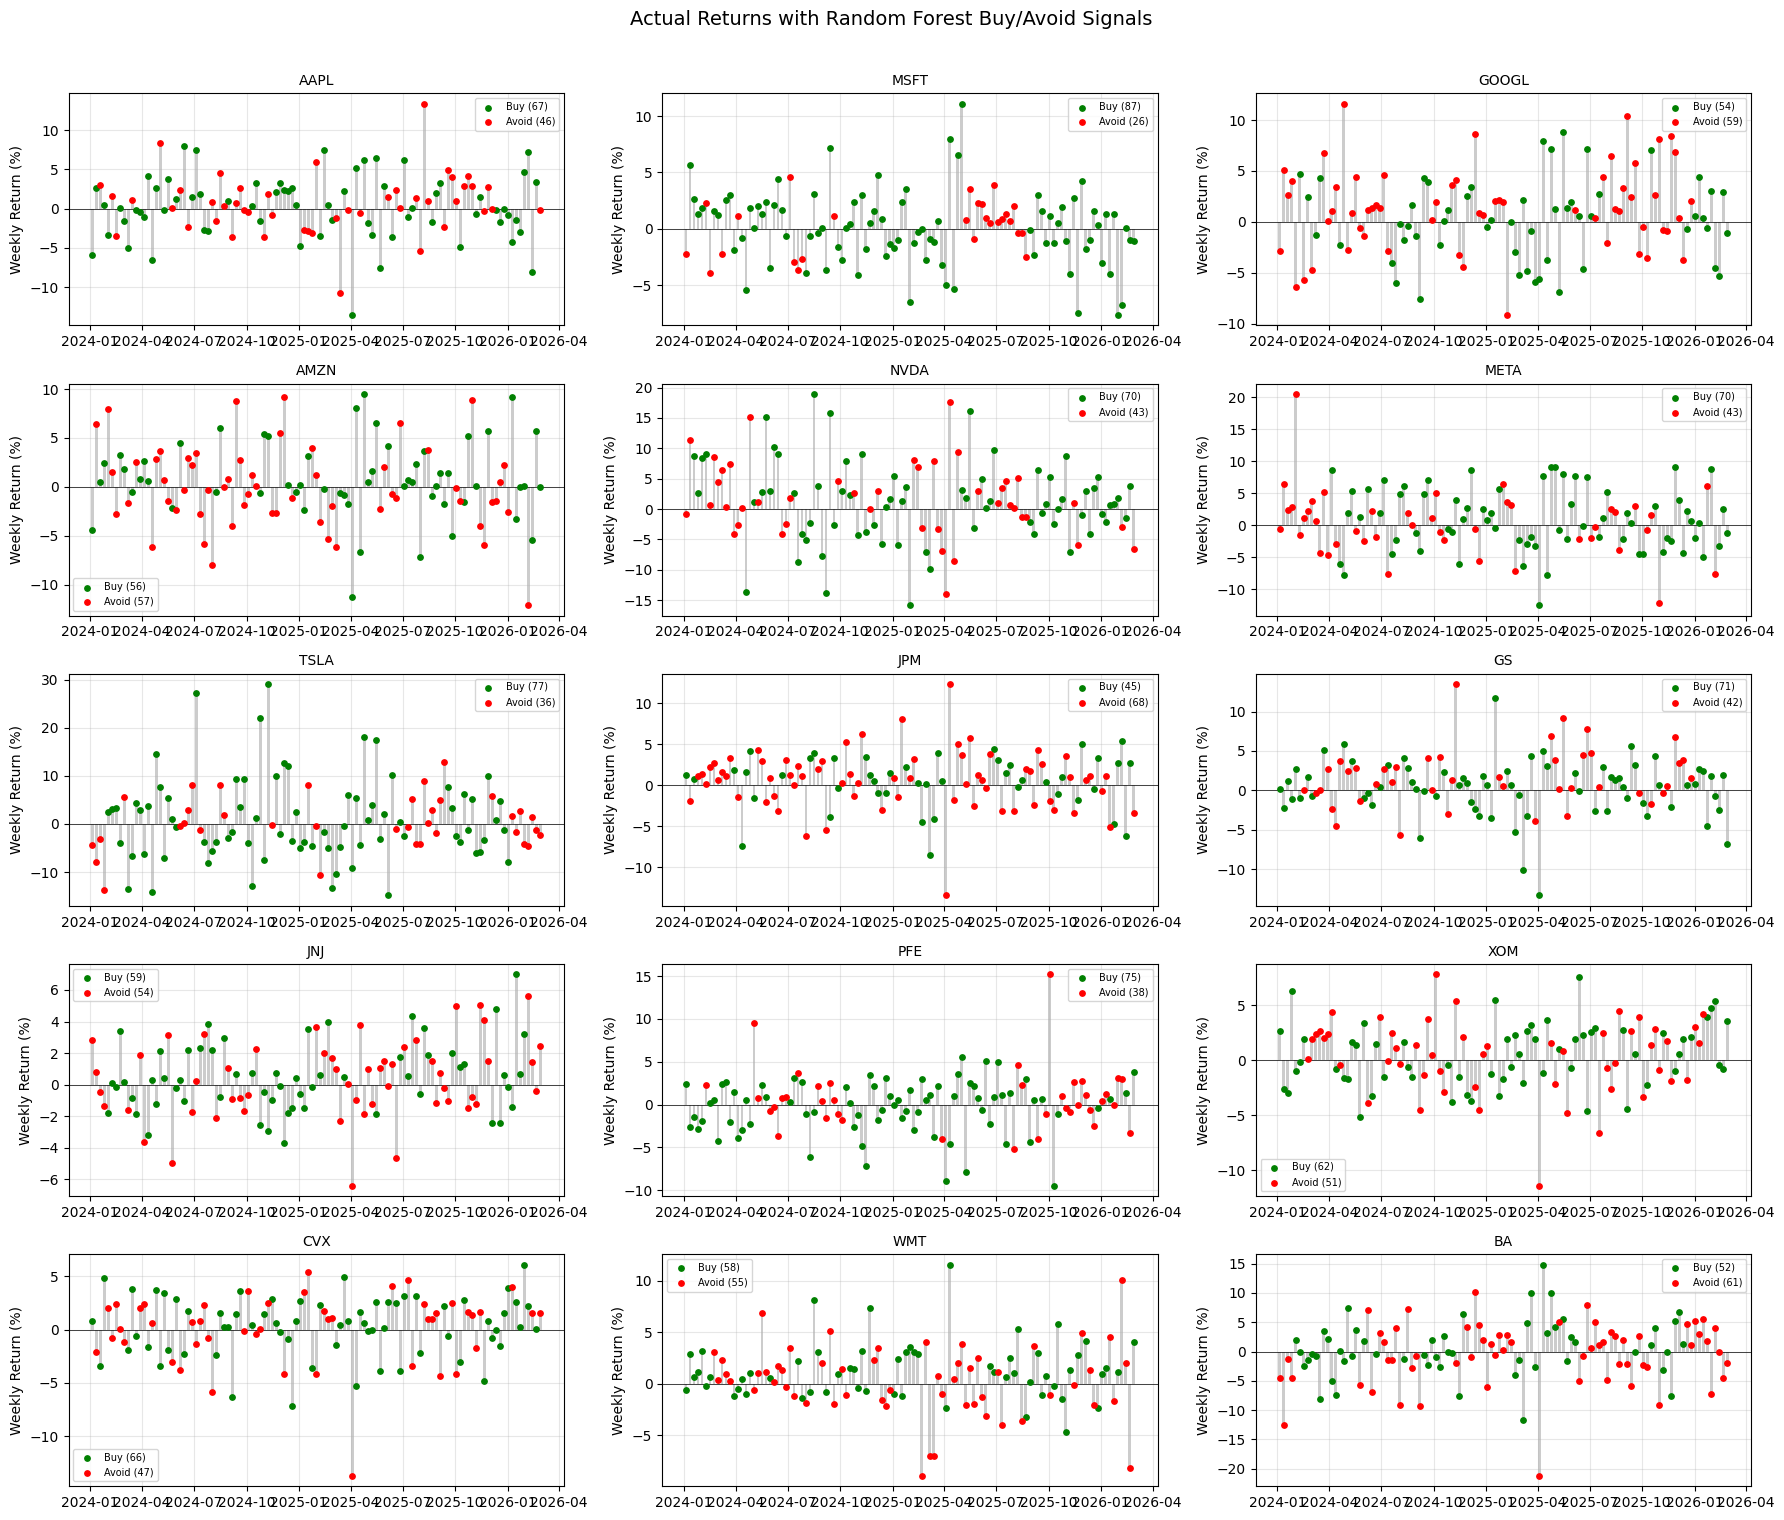

Saved: ../../data/results/rf_signals.png


In [12]:
n_cols = 3
n_rows = (len(TICKERS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    td = pred_df[pred_df['Ticker'] == ticker].sort_values('Date')
    ax.bar(td['Date'], td['Actual_Return'], alpha=0.4, width=5, color='gray')
    buy  = td[td['Pred_Direction'] == 1]
    sell = td[td['Pred_Direction'] == 0]
    ax.scatter(buy['Date'],  buy['Actual_Return'],  color='green', s=15,
               label=f'Buy ({len(buy)})',    zorder=5)
    ax.scatter(sell['Date'], sell['Actual_Return'], color='red',   s=15,
               label=f'Avoid ({len(sell)})', zorder=5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(f'{ticker}', fontsize=10)
    ax.set_ylabel('Weekly Return (%)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Actual Returns with Random Forest Buy/Avoid Signals', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_signals.png')

## 12. Confusion Matrices

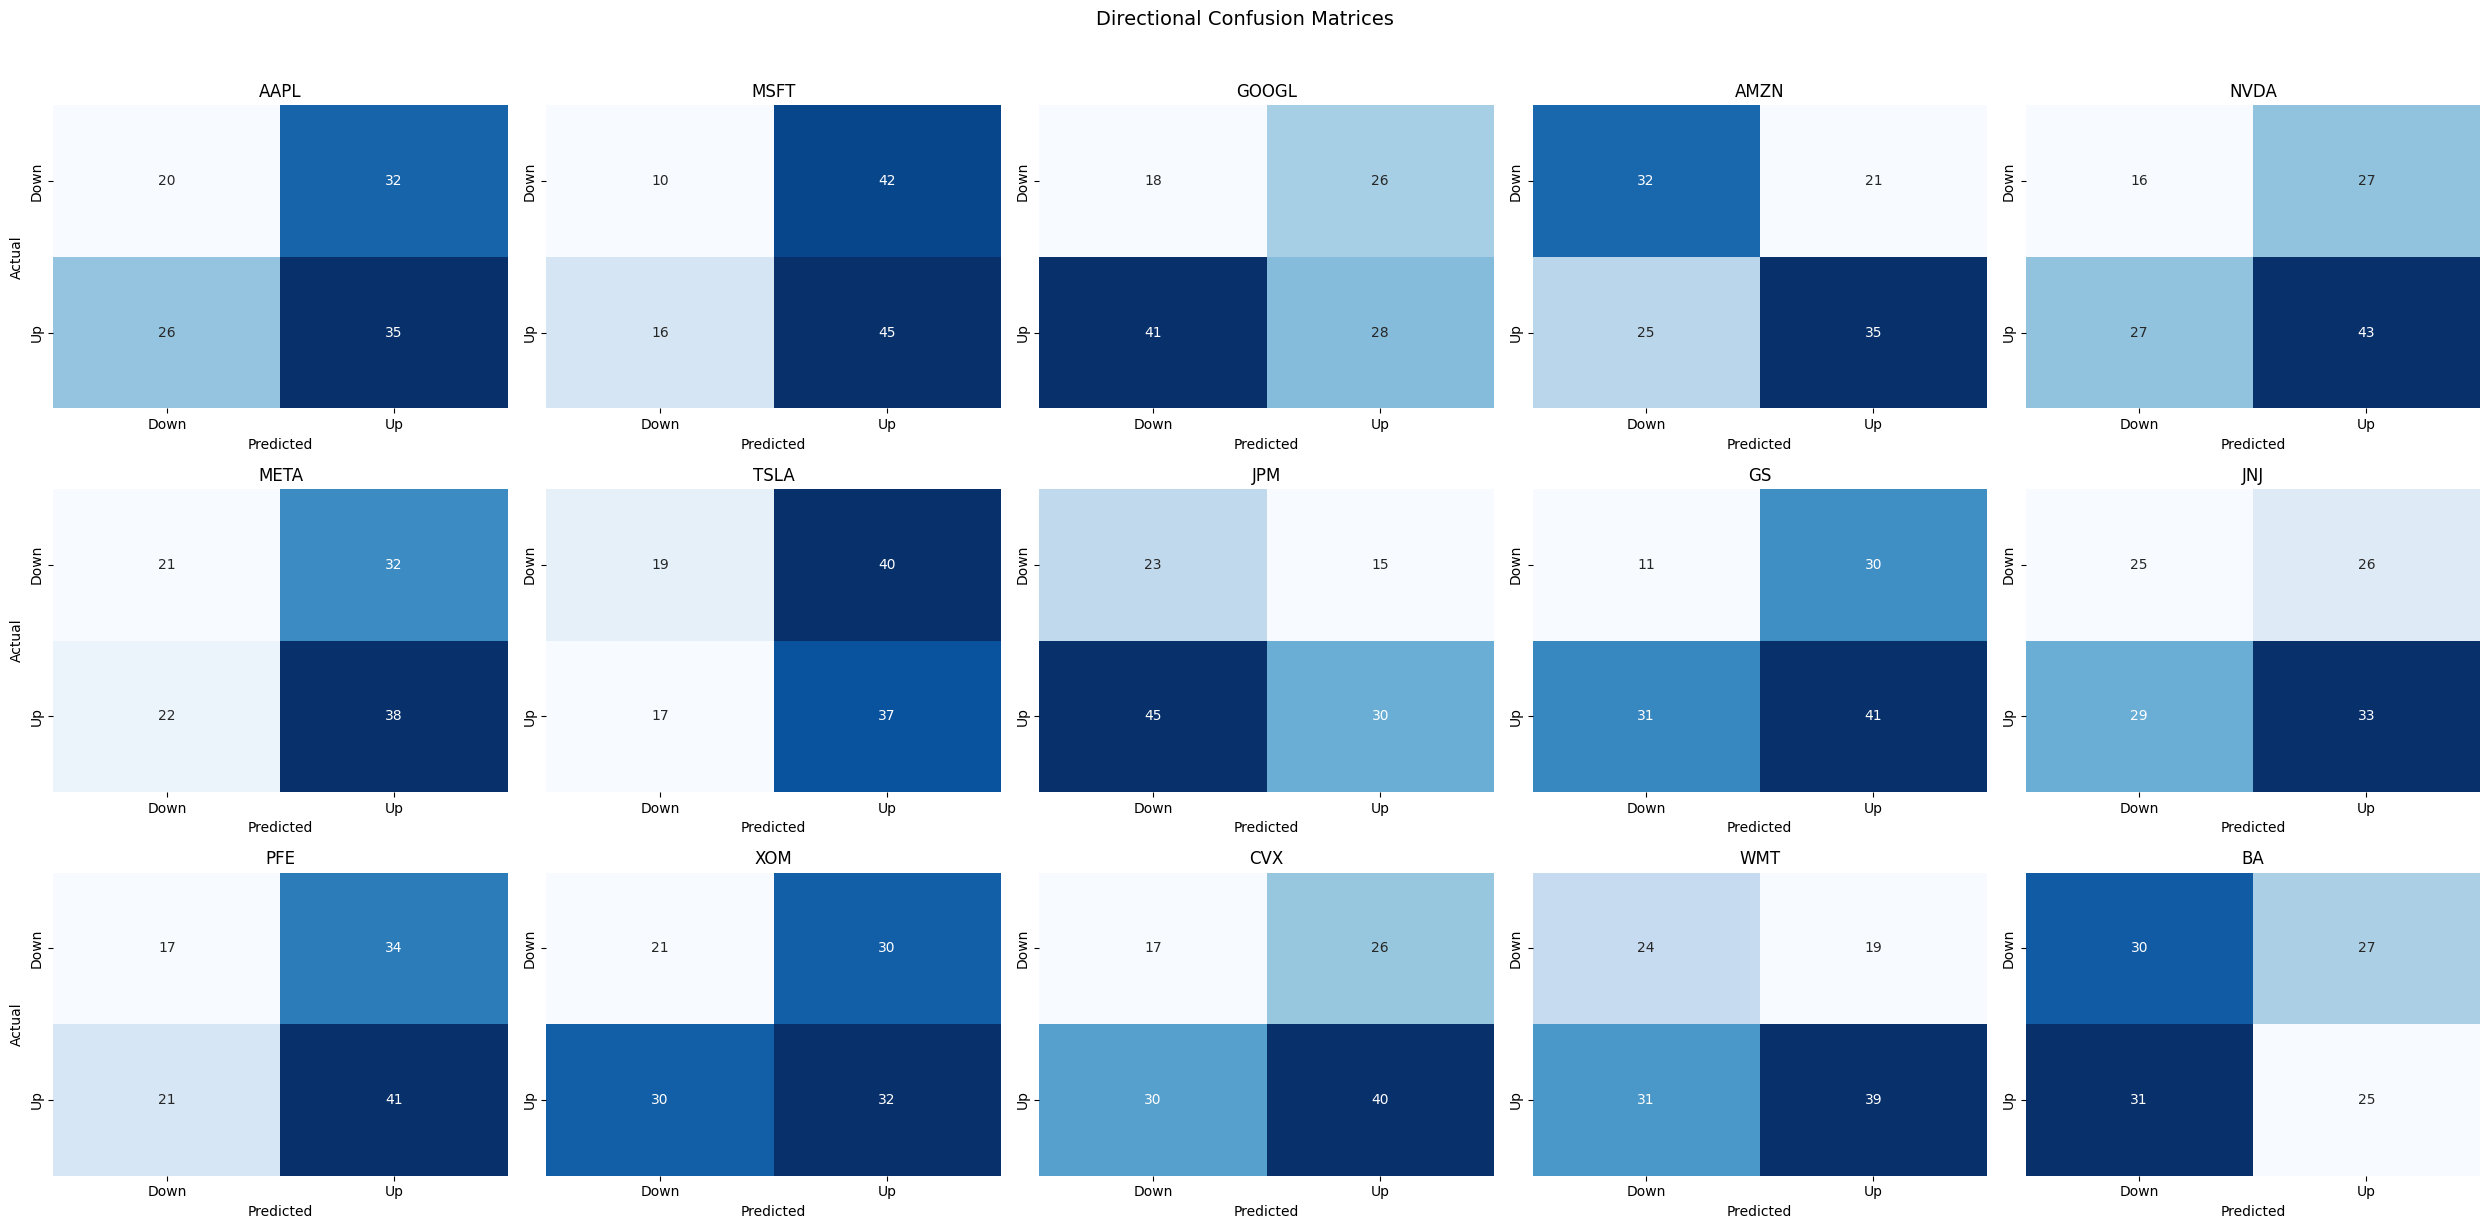

Saved: ../../data/results/rf_confusion_matrices.png


In [13]:
n_cols = 5
n_rows = (len(TICKERS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    td = pred_df[pred_df['Ticker'] == ticker]
    cm = confusion_matrix(td['Actual_Direction'], td['Pred_Direction'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], cbar=False)
    axes[i].set_title(f'{ticker}', fontsize=12)
    axes[i].set_xlabel('Predicted')
    if i % n_cols == 0:
        axes[i].set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Directional Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_confusion_matrices.png')

## 13. Feature Importance

A key advantage of Random Forest over LSTM — it shows which features drove predictions most. Higher importance = more influence across tree splits.

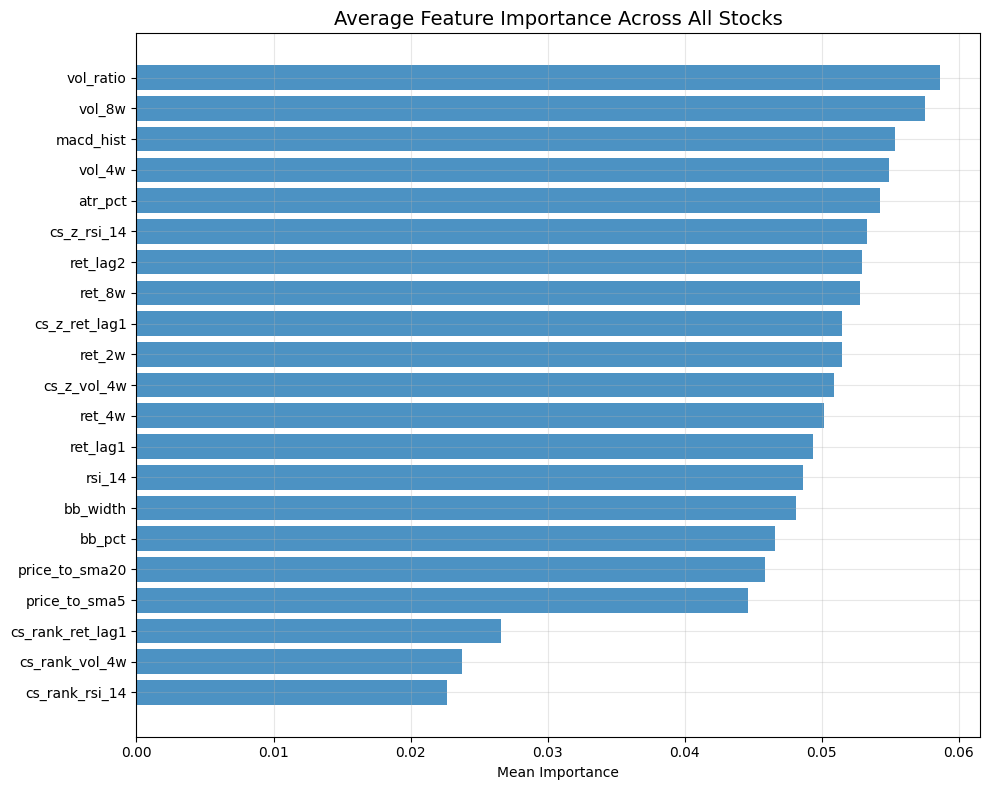

Saved: ../../data/results/rf_feature_importance.png

Top 5 most important features:
vol_ratio    0.058621
vol_8w       0.057561
macd_hist    0.055328
vol_4w       0.054882
atr_pct      0.054273


In [14]:
importance_df = pd.DataFrame(index=feature_cols)
for ticker in TICKERS:
    model, _ = all_models[ticker]
    importance_df[ticker] = model.feature_importances_

importance_df['Mean'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df.index, importance_df['Mean'], color='#1f77b4', alpha=0.8)
ax.set_title('Average Feature Importance Across All Stocks', fontsize=14)
ax.set_xlabel('Mean Importance')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_feature_importance.png')

print('\nTop 5 most important features:')
print(importance_df['Mean'].tail(5).sort_values(ascending=False).to_string())

## 14. Weekly Stock Rankings

Each week, rank all 15 stocks by predicted probability. Rank 1 = most likely to outperform. With 15 stocks, random baseline is 6.7%.

In [15]:
pivot_pred   = pred_df.pivot_table(index='Date', columns='Ticker', values='Predicted_Return')
pivot_actual = pred_df.pivot_table(index='Date', columns='Ticker', values='Actual_Return')

predicted_ranks = pivot_pred.rank(axis=1, ascending=False).astype(int)
actual_ranks    = pivot_actual.rank(axis=1, ascending=False).astype(int)

rank_matches = (predicted_ranks == actual_ranks).mean()
print('Per-stock ranking accuracy:')
for ticker in TICKERS:
    if ticker in rank_matches:
        bar = '#' * int(rank_matches[ticker] * 50)
        print(f'  {ticker}: {rank_matches[ticker]:.1%}  {bar}')

n = len(TICKERS)
overall_rank_acc = (predicted_ranks == actual_ranks).values.mean()
print(f'\nOverall ranking accuracy: {overall_rank_acc:.1%}  (random: {1/n:.1%})')

pred_top1   = pivot_pred.idxmax(axis=1)
actual_top1 = pivot_actual.idxmax(axis=1)
top1_acc    = (pred_top1 == actual_top1).mean()
print(f'Top-1 accuracy: {top1_acc:.1%}  (random: {1/n:.1%})')

top2_acc_list = []
for date in pivot_pred.index:
    pred_top2   = pivot_pred.loc[date].nlargest(2).index.tolist()
    actual_best = pivot_actual.loc[date].idxmax()
    top2_acc_list.append(actual_best in pred_top2)
top2_acc = np.mean(top2_acc_list)
print(f'Top-2 accuracy: {top2_acc:.1%}  (random: {2/n:.1%})')

predicted_ranks.to_csv(f'{OUT_DIR}/rf_rankings.csv')
print(f'\nSaved: {OUT_DIR}/rf_rankings.csv')

Per-stock ranking accuracy:
  AAPL: 4.4%  ##
  MSFT: 4.4%  ##
  GOOGL: 6.2%  ###
  AMZN: 7.1%  ###
  NVDA: 6.2%  ###
  META: 7.1%  ###
  TSLA: 4.4%  ##
  JPM: 4.4%  ##
  GS: 9.7%  ####
  JNJ: 1.8%  
  PFE: 6.2%  ###
  XOM: 8.0%  ###
  CVX: 8.0%  ###
  WMT: 10.6%  #####
  BA: 6.2%  ###

Overall ranking accuracy: 6.3%  (random: 6.7%)
Top-1 accuracy: 6.2%  (random: 6.7%)
Top-2 accuracy: 14.2%  (random: 13.3%)

Saved: ../../data/results/rf_rankings.csv


## 15. Ranking Heatmap

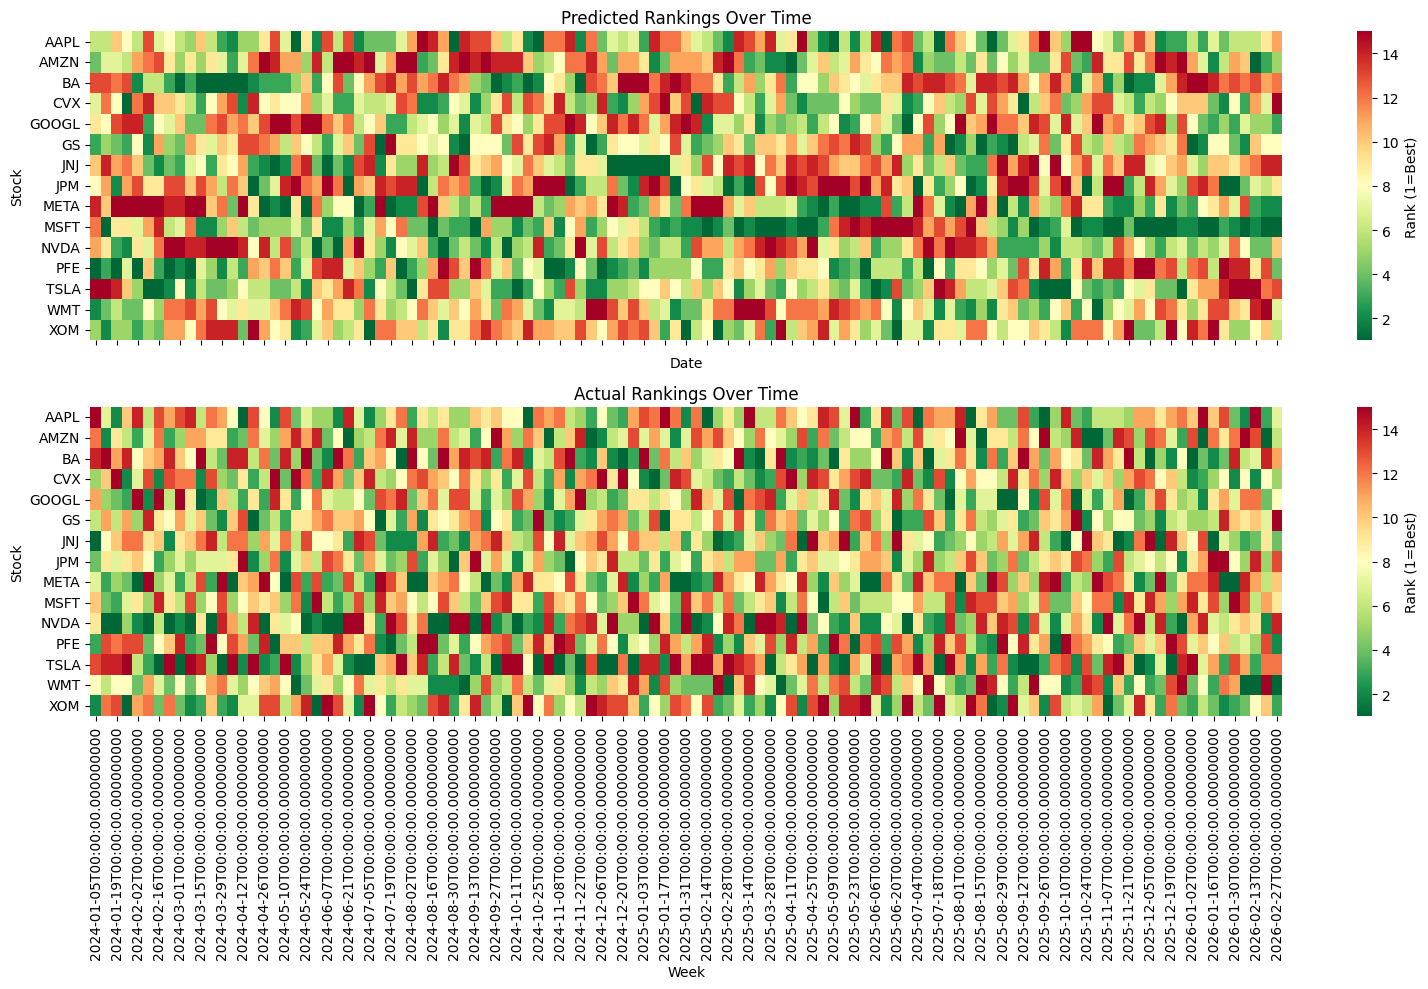

Saved: ../../data/results/rf_ranking_heatmap.png


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

sns.heatmap(predicted_ranks.T, cmap='RdYlGn_r', ax=axes[0],
            cbar_kws={'label': 'Rank (1=Best)'}, linewidths=0)
axes[0].set_title('Predicted Rankings Over Time', fontsize=12)
axes[0].set_ylabel('Stock')
axes[0].set_xticklabels([])

sns.heatmap(actual_ranks.T, cmap='RdYlGn_r', ax=axes[1],
            cbar_kws={'label': 'Rank (1=Best)'}, linewidths=0)
axes[1].set_title('Actual Rankings Over Time', fontsize=12)
axes[1].set_ylabel('Stock')
axes[1].set_xlabel('Week')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_ranking_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_ranking_heatmap.png')

## 16. Save Summary

In [17]:
metrics_df = pd.DataFrame(all_metrics).T
metrics_df.index.name = 'Ticker'
metrics_df.to_csv(f'{OUT_DIR}/rf_metrics.csv')

with open(f'{OUT_DIR}/rf_summary.txt', 'w') as f:
    f.write('Random Forest Model Summary\n')
    f.write('=' * 50 + '\n\n')
    f.write('Approach: Binary Classification (Up vs Down)\n')
    f.write('No lookahead: all features shifted 1 week\n')
    f.write('n_estimators=200, max_depth=6, min_samples_leaf=5\n')
    f.write('max_features=sqrt, class_weight=balanced, oob_score=True\n\n')
    f.write('Per-Stock Metrics:\n')
    f.write(metrics_df.to_string())
    f.write(f'\n\nOverall Ranking Accuracy: {overall_rank_acc:.1%} (random: {1/n:.1%})\n')
    f.write(f'Top-1 Accuracy: {top1_acc:.1%} (random: {1/n:.1%})\n')
    f.write(f'Top-2 Accuracy: {top2_acc:.1%} (random: {2/n:.1%})\n')

print(f'Saved: {OUT_DIR}/rf_metrics.csv')
print(f'Saved: {OUT_DIR}/rf_summary.txt')
print('\nRandom Forest modeling complete!')
print('Next step: add rf_predictions.csv to backtest notebook')

Saved: ../../data/results/rf_metrics.csv
Saved: ../../data/results/rf_summary.txt

Random Forest modeling complete!
Next step: add rf_predictions.csv to backtest notebook


## 17. Why Random Forest for Stock Prediction?

### Ensemble Learning via Bagging
Random Forest builds 200 decision trees, each trained on a random bootstrap sample (~63%) of the training data. Each tree votes independently, and the final probability is the average across all trees. This bagging approach reduces variance — a single decision tree would overfit the noisy financial data, but averaging 200 trees smooths out the noise considerably.

### No Lookahead Bias
All features are shifted by one week before training. When predicting week T's direction, the model only sees data available at the close of week T-1. This is critical for a realistic simulation — using the current week's RSI or return in the feature set would constitute data leakage and produce artificially inflated accuracy.

### Comparison to LSTM
The LSTM uses a 4-week sequence to capture temporal patterns — it has memory of the past. Random Forest treats each week independently using only last week's features. This makes Random Forest faster to train and easier to interpret via feature importance, but it misses momentum effects that LSTM can capture through sequential learning.

### Out-of-Bag (OOB) Error
Because each tree only sees ~63% of training data, the remaining ~37% acts as a free validation set per tree. The OOB accuracy is an unbiased generalization estimate without needing a separate validation split — a unique advantage of bagging.

### With 15 Stocks Across Sectors
Expanding to 15 stocks across tech, finance, healthcare, energy, and consumer sectors reduces the correlation problem. Random baseline drops from 20% (5 stocks) to 6.7% (15 stocks), making any accuracy above baseline statistically more meaningful. Cross-sector dispersion also gives the model more opportunity to identify true weekly winners.

### Limitations
- No temporal memory — treats each week independently
- Feature importance can be misleading when features are correlated
- Cannot adapt to market regime changes without retraining
- Like all models, performance degrades in market conditions unseen during training